# Lecture 4 - Solutions

Run cells from top to bottom. Use these worked answers after completing the three exercises. The examples retain the supplied signal parameters, recording, every-third-sample downsampling and full FFT approach.

The simple first-half amplitude expression also doubles DC and omits the Nyquist bin. For an odd number of samples, `[:N//2]` additionally omits the highest positive-frequency bin. These are amplitude plots, not power spectral density plots.

In [1]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import urllib.request
import librosa
from IPython import display

## Exercise 1 - Aliasing in a spectrum

Create time-series data, then use the FFT to create a spectrum plot in which aliasing is present.

- Use a sample rate of 1,000 Hz, a sine frequency of 600 Hz and a duration of five seconds.
- What frequency will appear in the spectrum? Explain your prediction and compare it with the plot.
- Use the full `scipy.fft.fft` and `scipy.fft.fftfreq`, selecting the first half with `[:N//2]`. Plot `2.0/N * np.abs(yf[:N//2])` and label the axes “Frequency (Hz)” and “Magnitude”.


### Solution

The Nyquist frequency is 500 Hz. A 600 Hz sine sampled at 1,000 Hz aliases to 400 Hz. The negative-frequency partner gives the matching peak on the other side of the full spectrum. Use `endpoint=False` so consecutive samples are exactly 1/1,000 second apart.


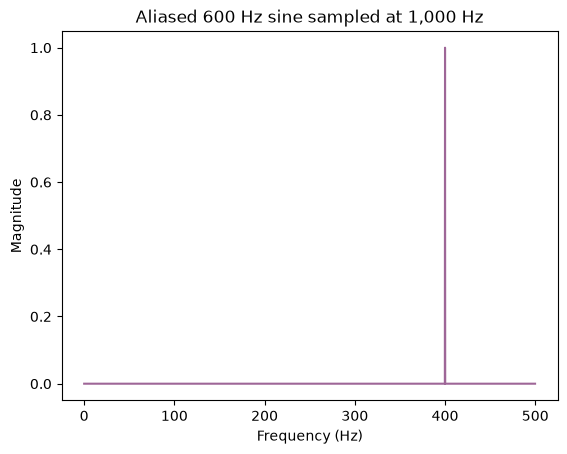

In [2]:
# Some parameters
sample_rate = 1000
frequency = 600
n_seconds = 5

time = np.linspace(0, n_seconds, sample_rate * n_seconds, endpoint=False)
sine = np.sin(time * 2 * np.pi * frequency)

# Number of sample points
N = len(sine)
yf = fft(sine)
xf = fftfreq(N, 1 / sample_rate)[:N//2]
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]), color="#9e6697")
plt.title("Aliased 600 Hz sine sampled at 1,000 Hz")
plt.ylabel("Magnitude")
plt.xlabel("Frequency (Hz)")
plt.show()

## Exercise 2 - Keep every third audio sample

Download and load an MP3 file in Python using the supplied example, following the same method as in the previous lectures. Downsample it by a factor of three, keeping every third data point with `[::3]`. Play the original sound, then play the downsampled sound. What has happened?

Keep the original recording sample rate when loading with `librosa.load(..., sr=None)`. Use the original sample rate for the original audio and one third of that rate for the downsampled audio. Print the first ten samples of both arrays to inspect which samples are retained.

The supplied example uses BigSoundBank recording 1064, Level Crossing Warning, the same recording as in the original solution.

```python
import urllib.request
import librosa
from IPython import display

file_name = "1064.mp3"
url = f"https://bigsoundbank.com/UPLOAD/mp3/{file_name}"
urllib.request.urlretrieve(url, file_name)
sound_data, samplerate = librosa.load(file_name, sr=None)
display.display(display.Audio(data=sound_data, rate=samplerate, normalize=False))
```

Source: [https://bigsoundbank.com/level-crossing-warning-s1064.html](https://bigsoundbank.com/level-crossing-warning-s1064.html)


### Solution

Download the same recording as MP3, load it with `librosa.load(file_name, sr=None)` and play it at its original rate. Keep every third sample and play the shorter array at one third of the original rate. This preserves the duration rather than playing the same samples three times faster.

This is unfiltered downsampling, not anti-aliased resampling. Components above the new Nyquist frequency can fold into the lower-frequency range. The sound may change in timbre. Listen to both players to describe the change you hear. Both players use `normalize=False` so automatic rescaling does not hide differences in loudness.


In [3]:
file_name = "1064.mp3"
url = f"https://bigsoundbank.com/UPLOAD/mp3/{file_name}"
urllib.request.urlretrieve(url, file_name)
sound_data, samplerate = librosa.load(file_name, sr=None)
display.display(display.Audio(data=sound_data, rate=samplerate, normalize=False))

In [4]:
sound_data_decimated = sound_data[::3]
decimated_samplerate = samplerate / 3

print(f"First bit of original signal: {sound_data[:10]}")
print(f"First bit of decimated signal: {sound_data_decimated[:10]}")
print(f"Original sample rate: {samplerate:g} Hz")
print(f"Downsampled sample rate: {decimated_samplerate:g} Hz")

display.display(display.Audio(data=sound_data_decimated, rate=decimated_samplerate, normalize=False))

First bit of original signal: [-4.0956598e-05  5.9899059e-05  1.4894710e-04  2.3809420e-04
  3.1329849e-04  3.2924186e-04  1.4852255e-04 -2.1152990e-04
 -3.5150757e-04 -2.1950458e-04]
First bit of decimated signal: [-4.0956598e-05  2.3809420e-04  1.4852255e-04 -2.1950458e-04
 -3.6728708e-04  1.3238007e-04  1.6998738e-03  2.1271475e-03
 -1.9196598e-03 -1.9010054e-03]
Original sample rate: 48000 Hz
Downsampled sample rate: 16000 Hz


## Exercise 3 - Compare the spectra

Plot an FFT of the original and downsampled sound from Exercise 2. Does this confirm what you previously noticed?

Use each signal's own sample count and sample rate to construct its frequency axis. Use the full FFT and the first-half amplitude plot from Exercise 1. Give both plots labelled axes and compare them over the same frequency range.


### Solution

Use the same full FFT calculation for both arrays, with each array's own length and sample rate. The original recording uses 48,000 Hz, while the downsampled recording uses 16,000 Hz. Their Nyquist frequencies are therefore 24,000 Hz and 8,000 Hz.

The downsampled spectrum cannot retain frequencies above 8,000 Hz as distinct frequencies. Unfiltered downsampling folds their contributions into the retained range. Compare changes in the peaks and relate them to what you heard. Not every lower-frequency peak is necessarily caused by aliasing because the original already contains low-frequency components.


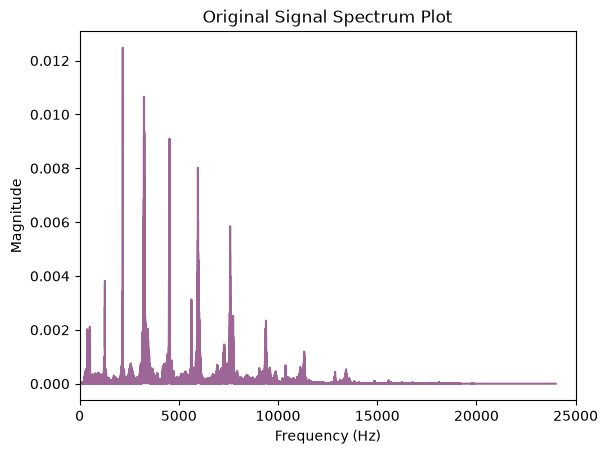

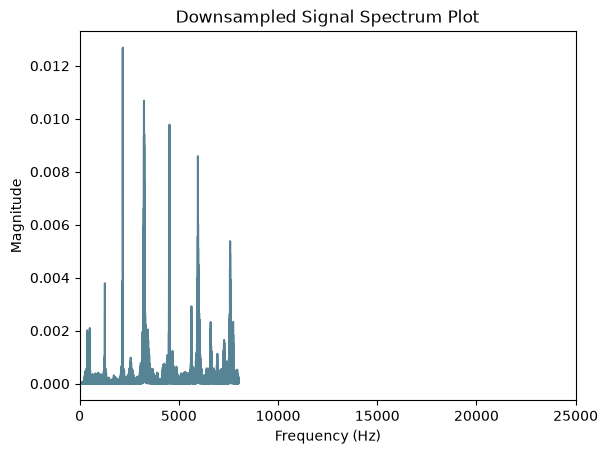

In [5]:
N = len(sound_data)
yf = fft(sound_data)
xf = fftfreq(N, 1 / samplerate)[:N//2]
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]), color="#9e6697")
plt.xlim(0, 25000)
plt.title("Original Signal Spectrum Plot")
plt.ylabel("Magnitude")
plt.xlabel("Frequency (Hz)")
plt.show()

N = len(sound_data_decimated)
yf = fft(sound_data_decimated)
xf = fftfreq(N, 1 / decimated_samplerate)[:N//2]
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]), color="#578494")
plt.xlim(0, 25000)
plt.title("Downsampled Signal Spectrum Plot")
plt.ylabel("Magnitude")
plt.xlabel("Frequency (Hz)")
plt.show()